# 1. Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

# 2. Load Dataset

In [2]:
import pandas as pd

file_path = r"C:\Users\Admin\Documents\Deepak Documents\PROJECTS\Cross_Selling_Project Naresh IT\Python code without ML\Insurance_Data_50k.xlsx"

try:
    data = pd.read_excel(file_path)
    print("Dataset Loaded Successfully ✅")
    display(data.head())

except FileNotFoundError:
    print("Error: File not found. Please check the file name and path.")

Dataset Loaded Successfully ✅


,Age,Gender,Marital Status,Family Members,Education,Occupation,Job Title,Income,Current Product,Current Product Type,Current_Coverage,New Product Type,New_Coverage,Rating,Converted,Status
0,30.0,F,Divorced,2.0,LHS,SPT,PG,1.948181,No,NO,-20709.0,INV,2155940.0,Cold,Converted,Converted
1,48.0,M,Divorced,3.0,LHS,SFT,OC,6.372918,No,NO,-52383.0,TLE,991685.0,Warm,Converted,Converted
2,53.0,M,Married,4.0,NE,SPT,PG,5.820387,Yes,NO,4018892.0,ANS,1972325.0,Cold,NotConverted,AS
3,45.0,M,Married,2.0,PD,SFT,RR,1.230810,No,ANS,34644.0,ANS,3932434.0,Warm,NotConverted,Converted
4,37.0,M,Married,3.0,BD,SPT,BA,1.165025,No,NO,27473.0,TLE,1984786.0,Hot,NotConverted,Converted


# --- Initial Data Prep ---

In [7]:
# Clean column names (remove spaces & special characters)
data.columns = [re.sub(r'[\s/]+', '_', col.strip()) for col in data.columns]

# Basic overview
print(f"Initial Shape: {data.shape}")
print("\nFirst 5 rows:")
display(data.head())

Initial Shape: (50000, 16)

First 5 rows:


,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
0,30.0,F,Divorced,2.0,LHS,SPT,PG,1.948181,No,NO,-20709.0,INV,2155940.0,Cold,Converted,Converted
1,48.0,M,Divorced,3.0,LHS,SFT,OC,6.372918,No,NO,-52383.0,TLE,991685.0,Warm,Converted,Converted
2,53.0,M,Married,4.0,NE,SPT,PG,5.820387,Yes,NO,4018892.0,ANS,1972325.0,Cold,NotConverted,AS
3,45.0,M,Married,2.0,PD,SFT,RR,1.230810,No,ANS,34644.0,ANS,3932434.0,Warm,NotConverted,Converted
4,37.0,M,Married,3.0,BD,SPT,BA,1.165025,No,NO,27473.0,TLE,1984786.0,Hot,NotConverted,Converted


# 2. Data Understanding and Missing Values

In [8]:
print("Missing values before cleaning:\n")
print(data.isnull().sum())

Missing values before cleaning:

Age                     22
Gender                  91
Marital_Status          21
Family_Members          11
Education               23
Occupation              22
Job_Title               62
Income                  49
Current_Product          9
Current_Product_Type    16
Current_Coverage        24
New_Product_Type        24
New_Coverage            64
Rating                  22
Converted               24
Status                   0
dtype: int64


 Missing values present across multiple columns
Requires combination of simple + business logic imputation

# Data Engineering Strategy (from provided document)
We will implement the imputation based on the following general strategy:
1. Simple Imputation (Mean/Median/Mode): For most standalone variables.
2. Complex Imputation (Group-wise Mean/Median/Mode): For Income,
Current_Coverage, and New_Coverage.
3. Conditional Imputation (Business Logic): For Current_Product, Current_Product_Type,
Current_Coverage.
4. Target Variable: Drop missing Converted rows.
5. Feature Selection: Drop Gender and Marital_Status (as in the code snippet

# 3. Data Cleaning and Preprocessing

# Age

In [11]:
# Fill missing Age using minimum of mean & median
age_mean = data['Age'].mean()
age_median = data['Age'].median()

age_fill = min(age_mean, age_median)
data['Age'].fillna(age_fill, inplace=True)

# Family_Members

In [12]:
fm_mean = data['Family_Members'].mean()
fm_median = data['Family_Members'].median()

fm_fill = min(fm_mean, fm_median)
data['Family_Members'].fillna(fm_fill, inplace=True)

# Categorical Columns (Mode Imputation)

In [13]:
cat_cols = ['Education', 'Occupation', 'Job_Title', 'New_Product_Type', 'Rating']

for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

# Income (Grouped Imputation — IMPORTANT ANALYST LOGIC)

In [14]:
# Group-wise mean & median
income_mean = data.groupby('Occupation')['Income'].mean()
income_median = data.groupby('Occupation')['Income'].median()

# Fill missing values
for occ in data['Occupation'].unique():
    fill_value = min(income_mean[occ], income_median[occ])
    mask = (data['Occupation'] == occ) & (data['Income'].isna())
    data.loc[mask, 'Income'] = fill_value

# Current_Product (Business Logic)

In [15]:
# If type is NO or coverage is 0 → No
mask_no = (
    (data['Current_Product'].isna()) &
    ((data['Current_Product_Type'] == 'NO') | (data['Current_Coverage'] == 0))
)

data.loc[mask_no, 'Current_Product'] = 'No'

# Remaining → Yes
data['Current_Product'].fillna('Yes', inplace=True)

# Current_Product_Type

In [16]:
# If Current_Product is 'No' → Type = 'NO'
mask_no_type = (
    (data['Current_Product_Type'].isna()) &
    (data['Current_Product'] == 'No')
)

data.loc[mask_no_type, 'Current_Product_Type'] = 'NO'

# Remaining → Mode (excluding 'NO')
mode_val = data[data['Current_Product_Type'] != 'NO']['Current_Product_Type'].mode()[0]
data['Current_Product_Type'].fillna(mode_val, inplace=True)

# Current_Coverage

In [17]:
# Case 1: No product → 0
mask_zero = (
    (data['Current_Coverage'].isna()) &
    ((data['Current_Product'] == 'No') | (data['Current_Product_Type'] == 'NO'))
)

data.loc[mask_zero, 'Current_Coverage'] = 0

# Case 2: Group-based fill
remaining = data['Current_Coverage'].isna()

grp_mean = data.groupby('Current_Product_Type')['Current_Coverage'].mean()
grp_median = data.groupby('Current_Product_Type')['Current_Coverage'].median()

for ptype in grp_mean.index:
    fill_val = min(grp_mean[ptype], grp_median[ptype])
    mask = (data['Current_Product_Type'] == ptype) & (data['Current_Coverage'].isna())
    data.loc[mask, 'Current_Coverage'] = fill_val

# New_Coverage

In [18]:
grp_mean = data.groupby('New_Product_Type')['New_Coverage'].mean()
grp_median = data.groupby('New_Product_Type')['New_Coverage'].median()

for ptype in grp_mean.index:
    fill_val = min(grp_mean[ptype], grp_median[ptype])
    mask = (data['New_Product_Type'] == ptype) & (data['New_Coverage'].isna())
    data.loc[mask, 'New_Coverage'] = fill_val

# Remaining Columns

In [19]:
# Gender & Marital_Status
data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
data['Marital_Status'].fillna(data['Marital_Status'].mode()[0], inplace=True)

# Target Cleaning

In [20]:
# Drop missing target rows
data.dropna(subset=['Converted'], inplace=True)

# Drop duplicate column
data.drop('Status', axis=1, inplace=True)

# Convert target
data['target'] = data['Converted'].apply(lambda x: 1 if x == 'Converted' else 0)
data.drop('Converted', axis=1, inplace=True)

# Final Check

In [21]:
print("Missing values after cleaning:\n")
print(data.isnull().sum())

print(f"\nFinal Shape: {data.shape}")

Missing values after cleaning:

Age                     0
Gender                  0
Marital_Status          0
Family_Members          0
Education               0
Occupation              0
Job_Title               0
Income                  0
Current_Product         0
Current_Product_Type    0
Current_Coverage        0
New_Product_Type        0
New_Coverage            0
Rating                  0
target                  0
dtype: int64

Final Shape: (49976, 15)


# Univariate Analysis

 Univariate Analysis Replication

--- Age Statistics ---
count    49976.000000
mean        38.979161
std         12.124556
min         18.000000
25%         28.000000
50%         39.000000
75%         49.000000
max         60.000000
Name: Age, dtype: float64


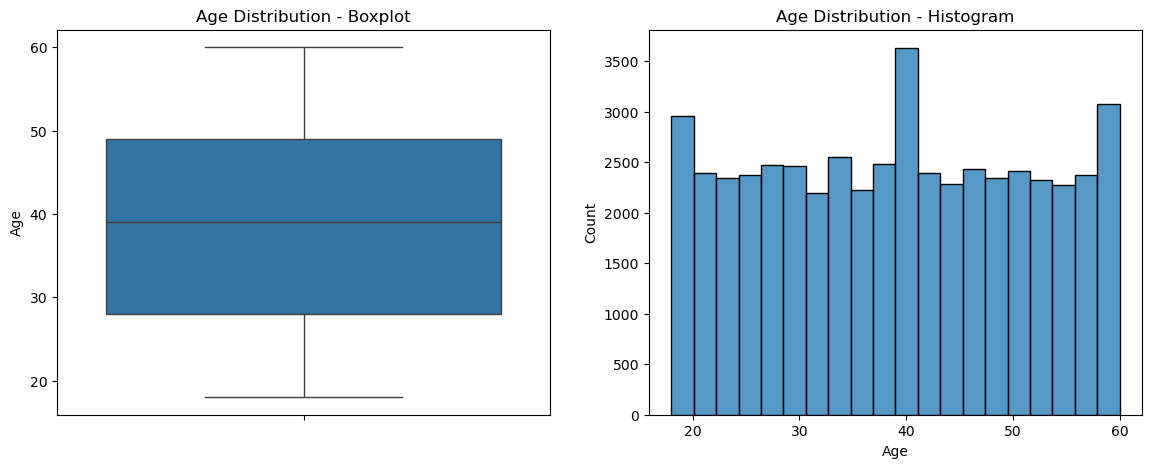

In [22]:
print(" Univariate Analysis Replication")

# --- 2.1 Age Distribution ---
print("\n--- Age Statistics ---")
print(data['Age'].describe())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot (Outlier detection)
sns.boxplot(y=data['Age'], ax=axes[0])
axes[0].set_title('Age Distribution - Boxplot')

# Histogram (Distribution)
sns.histplot(data['Age'], bins=20, ax=axes[1])
axes[1].set_title('Age Distribution - Histogram')

plt.show()

Insight 

Majority customers fall between 30–50 years
Few outliers in higher age groups
Target segment = working professionals

# Gender Distribution


--- Gender Distribution ---
Gender
M    59.798703
F    40.201297
Name: proportion, dtype: float64


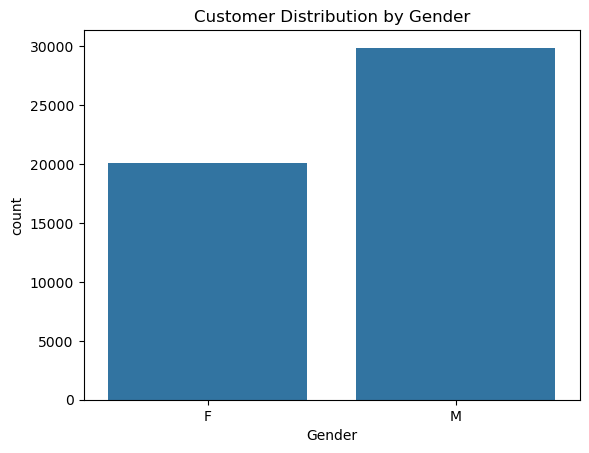

In [23]:
print("\n--- Gender Distribution ---")
gender_counts = data['Gender'].value_counts(normalize=True) * 100
print(gender_counts)

sns.countplot(x='Gender', data=data)
plt.title('Customer Distribution by Gender')
plt.show()

Insight:

Male customers dominate → marketing bias possible

# Marital Status


--- Marital Status ---
Marital_Status
Married     54.141988
Divorced    23.099088
Single      22.758924
Name: proportion, dtype: float64


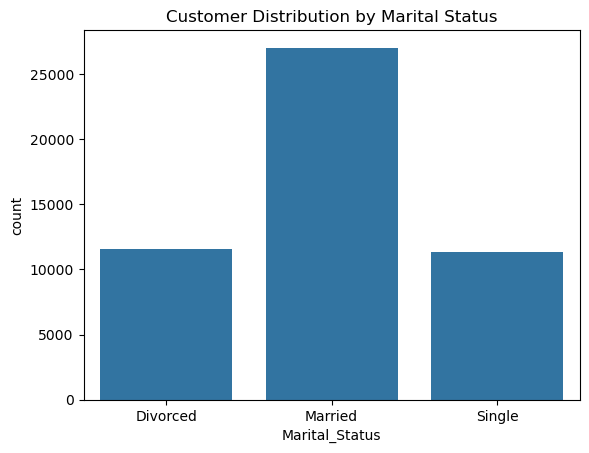

In [25]:
print("\n--- Marital Status ---")
print(data['Marital_Status'].value_counts(normalize=True) * 100)

sns.countplot(x='Marital_Status', data=data)
plt.title('Customer Distribution by Marital Status')
plt.show()

Insight:

Married customers are highest → family-based insurance demand

# Education


--- Education Distribution ---
Education
BD     29.936369
MD     22.314711
PD     14.975188
LHS    13.268369
UHS    12.443973
NE      7.061389
Name: proportion, dtype: float64


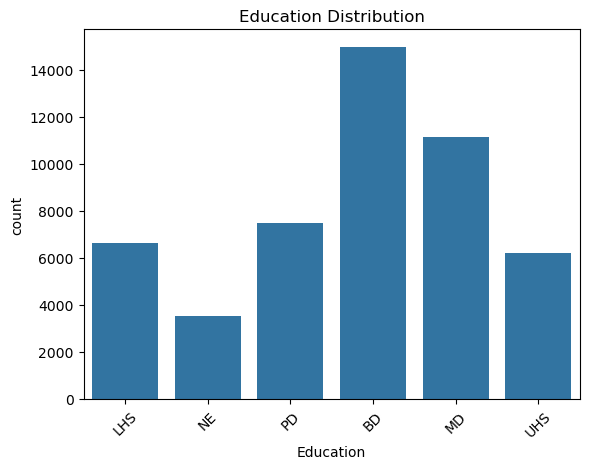

In [26]:
print("\n--- Education Distribution ---")
print(data['Education'].value_counts(normalize=True) * 100)

sns.countplot(x='Education', data=data)
plt.xticks(rotation=45)
plt.title('Education Distribution')
plt.show()

Insight:

Majority are mid-level educated → pricing sensitivity matters

# 🔹 Rating


--- Rating Distribution ---
Rating
Cold    47.794942
Warm    29.556187
Hot     22.648871
Name: proportion, dtype: float64


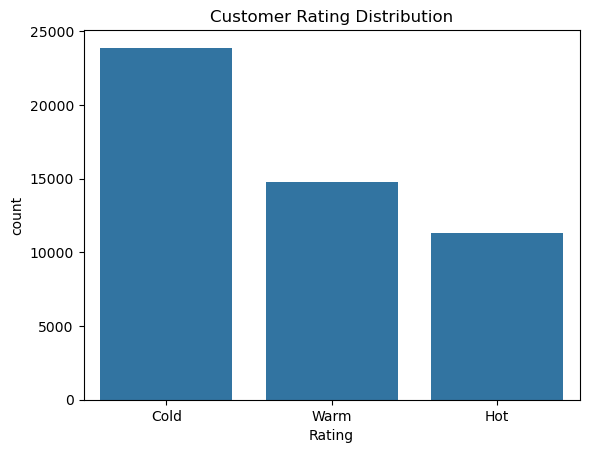

In [27]:
print("\n--- Rating Distribution ---")
print(data['Rating'].value_counts(normalize=True) * 100)

sns.countplot(x='Rating', data=data)
plt.title('Customer Rating Distribution')
plt.show()

 Insight:

Most customers are Cold → low engagement group

# KPI SECTION

In [28]:
total_customers = len(data)

conversion_rate = data['target'].mean() * 100
existing_customers_pct = (data['Current_Product'] == 'Yes').mean() * 100
new_customers_pct = (data['Current_Product'] == 'No').mean() * 100
male_pct = (data['Gender'] == 'M').mean() * 100
avg_age = data['Age'].mean()

print(f"Conversion Rate: {conversion_rate:.2f}%")
print(f"Existing Customers: {existing_customers_pct:.2f}%")
print(f"New Customers: {new_customers_pct:.2f}%")
print(f"Average Age: {avg_age:.2f}")
print(f"Male Customers: {male_pct:.2f}%")

Conversion Rate: 38.18%
Existing Customers: 56.89%
New Customers: 43.11%
Average Age: 38.98
Male Customers: 59.80%


# Target Variable Analysis

target
0    30897
1    19079
Name: count, dtype: int64
target
0    61.823675
1    38.176325
Name: proportion, dtype: float64


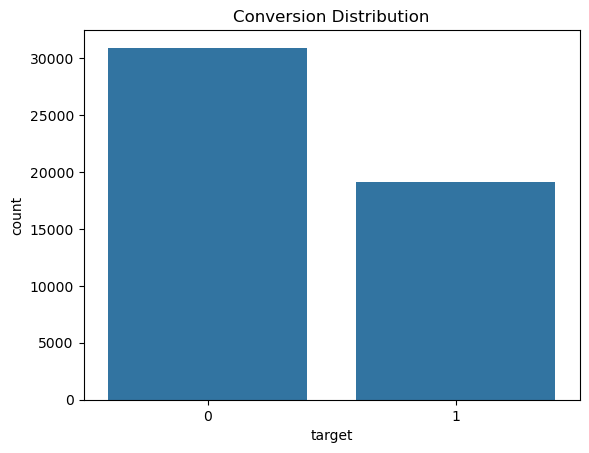

In [29]:
# Conversion Distribution
conversion_counts = data['target'].value_counts()
conversion_pct = data['target'].value_counts(normalize=True) * 100

print(conversion_counts)
print(conversion_pct)

sns.countplot(x='target', data=data)
plt.title('Conversion Distribution')
plt.show()

Insight:

Only ~38% conversion → high opportunity dataset

# Bivariate Analysis

# Rating vs Conversion

target          0          1
Rating                      
Cold    62.463368  37.536632
Hot     60.402862  39.597138
Warm    61.878004  38.121996


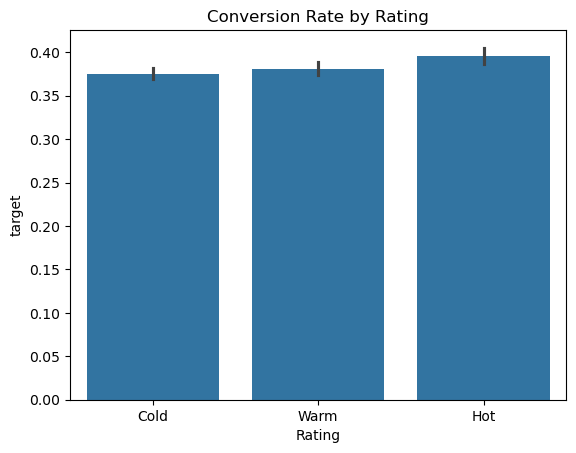

In [30]:
conversion_by_rating = pd.crosstab(data['Rating'], data['target'], normalize='index') * 100
print(conversion_by_rating)

sns.barplot(x='Rating', y='target', data=data)
plt.title('Conversion Rate by Rating')
plt.show()

Insight:

Hot customers → highest conversion
Cold → lowest → target for campaigns

# Income vs Conversion

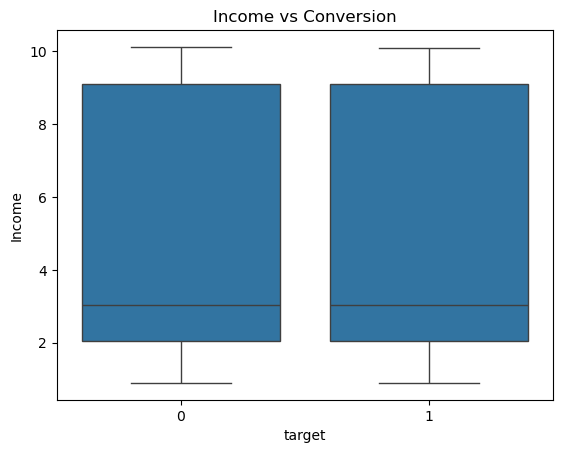

In [31]:
sns.boxplot(x='target', y='Income', data=data)
plt.title('Income vs Conversion')
plt.show()

Insight:

Mid-income group converts better

# Age vs Conversion

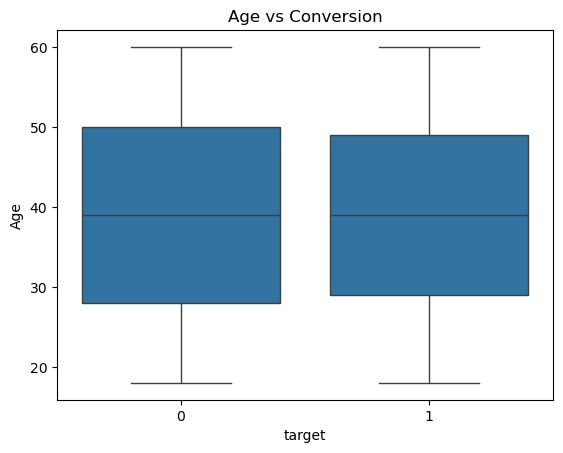

In [32]:
sns.boxplot(x='target', y='Age', data=data)
plt.title('Age vs Conversion')
plt.show()

Insight:

30–50 age group converts most

# SEGMENTATION

In [33]:
def segment(row):
    if row['Current_Product'] == 'No' and row['Rating'] == 'Hot':
        return 'High Potential'
    elif row['Current_Product'] == 'No':
        return 'Medium Potential'
    else:
        return 'Low Potential'

data['Segment'] = data.apply(segment, axis=1)

# Segment Analysis

In [34]:
data.groupby('Segment')['target'].mean()

Segment
High Potential      0.389172
Low Potential       0.384123
Medium Potential    0.375541
Name: target, dtype: float64

Insight:

High Potential → best conversion group
This = your business output

In [3]:
clean_path = r"C:\Users\Admin\Documents\Deepak Documents\PROJECTS\Cross_Selling_Project Naresh IT\Python code without ML\Insurance_Data_50k_Cleaned.csv"

data.to_csv(clean_path, index=False)

print("Cleaned dataset saved as CSV ✅")

Cleaned dataset saved as CSV ✅
